In [2]:
from typing import Literal, TypedDict

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
# define the state
# every node writes into its own key, so nothing gets overwritten


class ReviewState(TypedDict):
    review_text: str
    sentiment: str
    issue_type: str
    tone: str
    urgency: str
    response: str

In [4]:
# structured output schemas
# Literal keeps the model on a fixed vocabulary, so the routing stays predictable


class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative", "neutral"] = Field(
        description="The sentiment of the review"
    )


class DiagnosisSchema(BaseModel):
    issue_type: Literal["product", "service", "delivery"] = Field(
        description="The type of issue identified in the review"
    )
    tone: Literal["formal", "informal", "neutral"] = Field(
        description="The tone of the review"
    )
    urgency: Literal["high", "medium", "low"] = Field(
        description="The urgency of the issue"
    )

In [5]:
# one model instance shared by every node instead of rebuilding it on every call
model = ChatOpenAI(model="gpt-4o", temperature=0)

sentiment_model = model.with_structured_output(SentimentSchema)
diagnosis_model = model.with_structured_output(DiagnosisSchema)

In [6]:
def find_sentiment(state: ReviewState) -> ReviewState:
    prompt = (
        "Classify the sentiment of this customer review:\n\n"
        f"{state['review_text']}"
    )
    result = sentiment_model.invoke(prompt)

    return {"sentiment": result.sentiment}


def run_diagnosis(state: ReviewState) -> ReviewState:
    prompt = (
        "Diagnose this negative customer review. Identify the issue type, "
        "the tone and how urgent it is:\n\n"
        f"{state['review_text']}"
    )
    result = diagnosis_model.invoke(prompt)

    # the schema fields match the state keys, so the whole dict can be returned
    return result.model_dump()


def positive_response(state: ReviewState) -> ReviewState:
    response = "Thank you for your positive feedback! We're glad you had a great experience."

    return {"response": response}


def neutral_response(state: ReviewState) -> ReviewState:
    response = "Thank you for taking the time to share your feedback. We'll use it to improve."

    return {"response": response}


def negative_response(state: ReviewState) -> ReviewState:
    response = (
        "We're sorry to hear about your experience. "
        f"It seems there is an issue related to {state['issue_type']}. "
        f"The tone of your review is {state['tone']}, and we understand the urgency is {state['urgency']}. "
        "We will address this matter promptly."
    )

    return {"response": response}

In [7]:
# the routing function only picks the next node, it never writes to the state
# every returned value has to match a node name registered on the graph


def check_sentiment(
    state: ReviewState,
) -> Literal["positive_response", "run_diagnosis", "neutral_response"]:
    if state["sentiment"] == "positive":
        return "positive_response"
    elif state["sentiment"] == "negative":
        return "run_diagnosis"
    else:
        return "neutral_response"

In [8]:
# define the Graph and pass the state to it
graph = StateGraph(ReviewState)


# add nodes to the graph
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("neutral_response", neutral_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)


# add edges to the graph
graph.add_edge(START, "find_sentiment")

# the conditional edge: find_sentiment branches into one of the three paths
graph.add_conditional_edges("find_sentiment", check_sentiment)

# the negative path diagnoses the issue first, then writes the reply
graph.add_edge("run_diagnosis", "negative_response")

graph.add_edge("positive_response", END)
graph.add_edge("neutral_response", END)
graph.add_edge("negative_response", END)


# compile the graph
workflow = graph.compile()

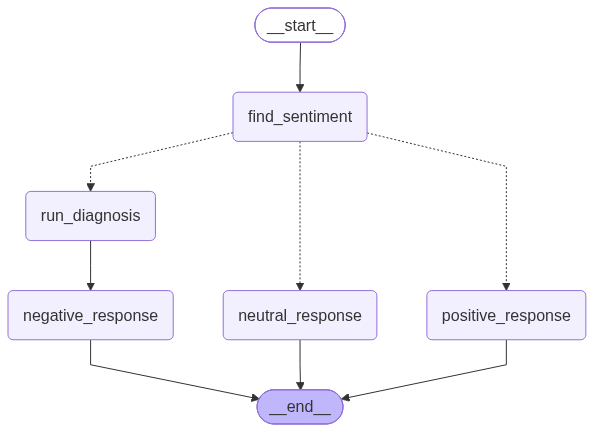

In [9]:
# visualize the graph
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [10]:
# execute the graph with some initial state
initial_state = {
    "review_text": "The laptop arrived with a cracked screen and support never replied to my emails."
}

output_state = workflow.invoke(initial_state)

print(output_state["sentiment"])
print(output_state["response"])

negative
We're sorry to hear about your experience. It seems there is an issue related to product. The tone of your review is informal, and we understand the urgency is high. We will address this matter promptly.
